In [1]:
import tensorflow as tf

IMG_HEIGHT = 28
IMG_WIDTH = 28
IMG_CHANNELS = 1
EPOCHS = 25
BATCH_SIZE = 16


CLASS_NAMES = ["T-Shirt", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

### Linear NN for images

In [2]:
import numpy as np
from tensorflow.keras.datasets import fashion_mnist

# 1. Load the full training data (60,000 images)
(x_train_full, y_train_full), (x_test_full, y_test_full) = fashion_mnist.load_data()



# 3. Split into 250 training and 20 testing images
X_train_small = x_train_full
y_train_small = y_train_full

X_test_small = x_test_full
y_test_small = y_test_full

print(f"Small Training Set Shape: {X_train_small.shape}")  # (250, 28, 28)
print(f"Small Testing Set Shape: {X_test_small.shape}")    # (20, 28, 28)


Small Training Set Shape: (60000, 28, 28)
Small Testing Set Shape: (10000, 28, 28)


In [3]:
# 3. Create the tf.data pipelines matching your exact style
train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_train_small, y_train_small))
    .batch(batch_size=BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

eval_dataset = (
    tf.data.Dataset.from_tensor_slices((X_test_small, y_test_small))
    .batch(batch_size=BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Quick verification check
print("Train batches:", len(list(train_dataset))) # 250 samples / 16 batch size = 15 batches
print("Eval batches:", len(list(eval_dataset)))   # 20 samples / 16 batch size = 2 batches

Train batches: 3750
Eval batches: 625


In [4]:
for image_batch, label_batch in eval_dataset.take(1):
    print("Image batch shape:", image_batch.shape)
    print("Label batch shape:", label_batch.shape)
    print("Labels:", label_batch.numpy())

Image batch shape: (16, 28, 28)
Label batch shape: (16,)
Labels: [9 2 1 1 6 1 4 6 5 7 4 5 7 3 4 1]


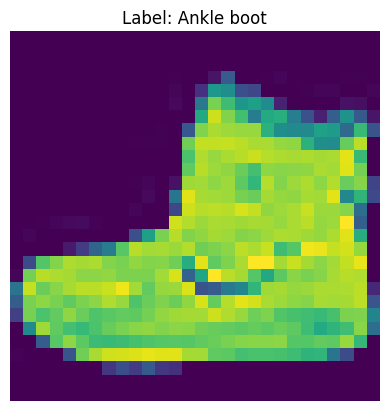

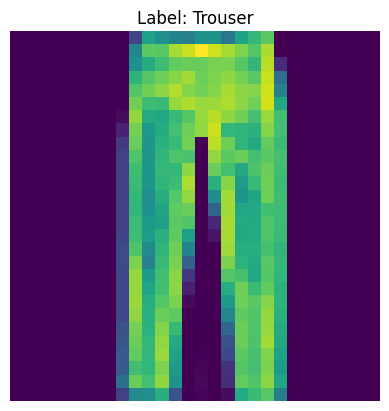

In [5]:
import matplotlib.pyplot as plt

for image_batch, label_batch in train_dataset.take(2):
    # Take the first image from the batch
    first_image = image_batch[0]
    first_label = label_batch[0]

    # Convert tensor to numpy array
    plt.imshow(first_image.numpy())
    plt.title(f"Label: {CLASS_NAMES[first_label]}")
    plt.axis('off')
    plt.show()

### Linear Neural Network for image classification 

In [6]:
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
    keras.layers.Dense(len(CLASS_NAMES), activation="softmax")
])

model.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

c:\Users\Debasish Das\.conda\envs\env1\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:

history = model.fit(
    train_dataset,
    validation_data=eval_dataset,
    epochs=EPOCHS
)

Epoch 1/25
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.7019 - loss: 25.3939 - val_accuracy: 0.7846 - val_loss: 27.0175
Epoch 2/25
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.7890 - loss: 16.2989 - val_accuracy: 0.7846 - val_loss: 37.8423
Epoch 3/25
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.7937 - loss: 16.0083 - val_accuracy: 0.7868 - val_loss: 23.3741
Epoch 4/25
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.7982 - loss: 15.0795 - val_accuracy: 0.7909 - val_loss: 24.7496
Epoch 5/25
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.7994 - loss: 14.7200 - val_accuracy: 0.7852 - val_loss: 23.8886
Epoch 6/25
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.8001 - loss: 15.4581 - val_accuracy: 0.7876 - val_loss: 28.3379
Epoch 7/25
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.8049 - loss: 15.1675 - val_accuracy: 0.7966 - val_loss: 24.7772
Epoch 8/25
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.

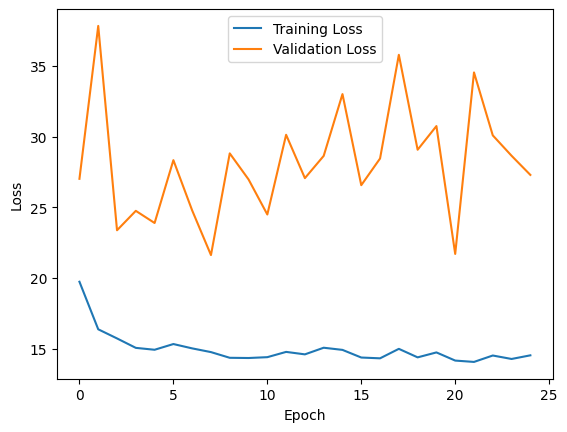

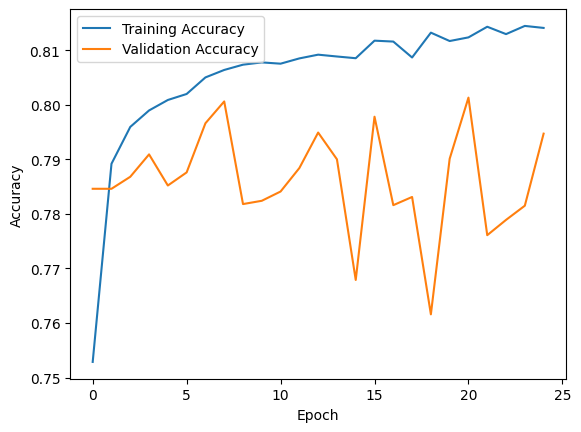

In [8]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


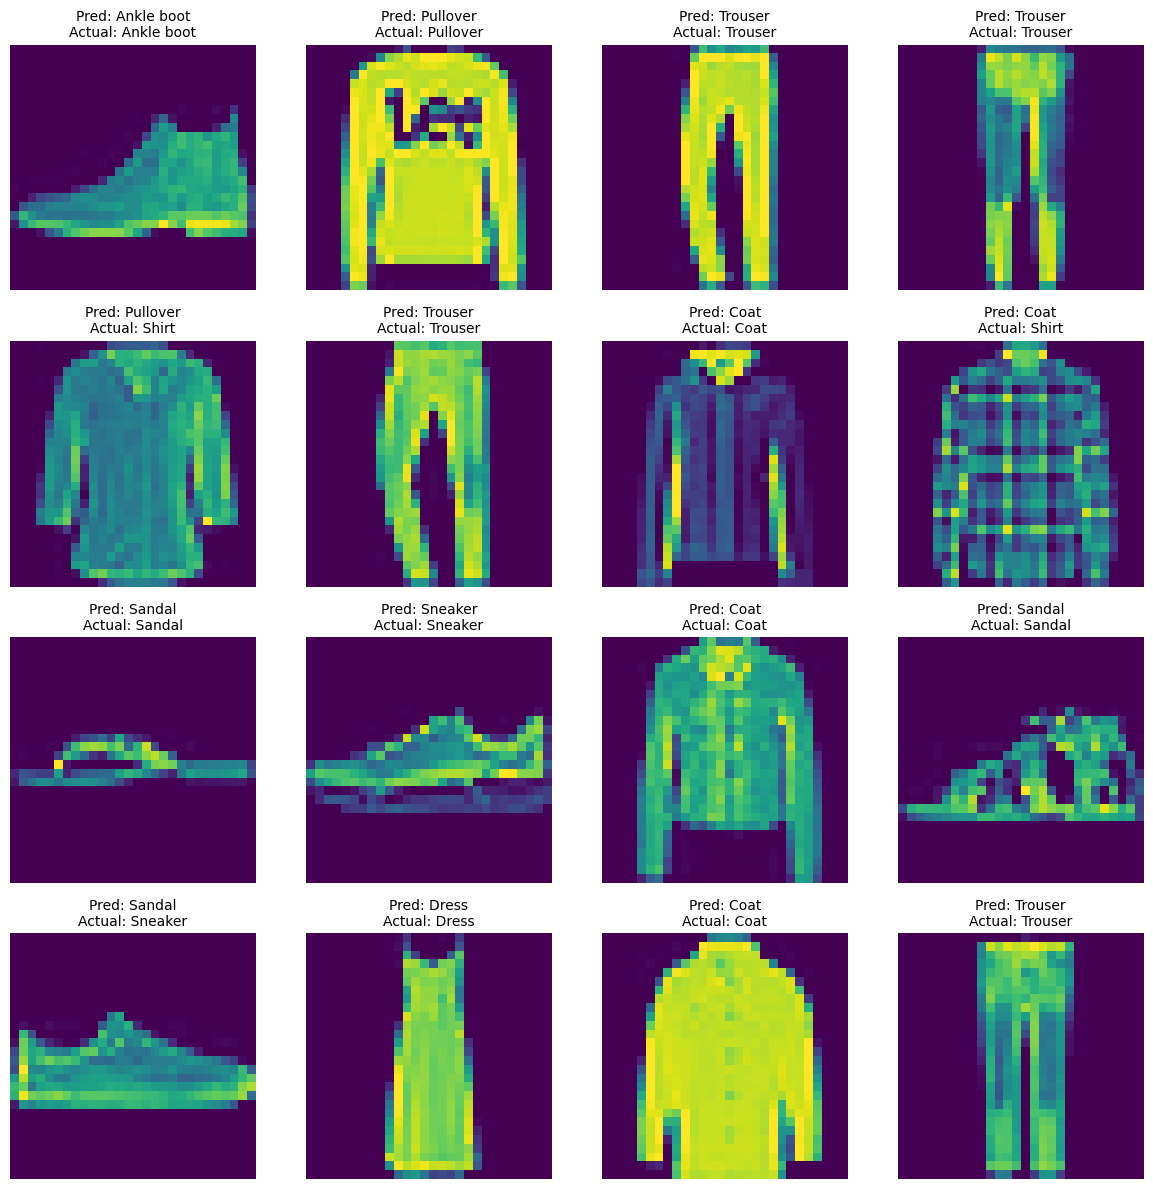

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Take exactly one batch from the evaluation dataset
for images, labels in eval_dataset.take(1):
    # Get model predictions for this batch
    batch_predictions = model.predict(images)
    predicted_indices = np.argmax(batch_predictions, axis=1)

    # Number of images in this batch
    num_images = images.shape[0]

    # Configure how many images to display per row
    num_cols = 4
    num_rows = math.ceil(num_images / num_cols)

    # Create a figure with a suitable size
    plt.figure(figsize=(12, 3 * num_rows))

    for i in range(num_images):
        plt.subplot(num_rows, num_cols, i + 1)

        # Display the image
        plt.imshow(images[i].numpy())
        plt.axis('off')

        # Get predicted and actual class names
        pred_class = CLASS_NAMES[predicted_indices[i]]
        actual_class = CLASS_NAMES[labels[i].numpy()]

        # Show both predicted and actual labels as title
        plt.title(f"Pred: {pred_class}\nActual: {actual_class}", fontsize=10)

    # Adjust spacing to avoid overlapping titles, etc.
    plt.tight_layout()
    plt.show()

## Add Non-linearities to the Current Model

- Val accuracy: 0.70 -0.75
- val loss: 29.65
- Model is Overfitting and not generalizing well to the validation set.

In [10]:
# add Dropout layer to the model to reduce overfitting
updated_model = keras.Sequential([
    keras.layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(64,activation="relu"),
    keras.layers.Dense(len(CLASS_NAMES), activation="softmax")
])

Number of parameters in the model: 
- 1st layer: 28 X 28 X 1= 784
- 2nd layer: 128 X 784 + 128 = 100,480 
- 3rd layer: 10 X 128 + 10 = 1,290
- Total parameters: 102,754
- Total size of the model: 102,754 X 4 bytes = 411,016 bytes = 0.39 MB


In [11]:
updated_model.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

In [12]:
updated_history=updated_model.fit(
    train_dataset,
    validation_data=eval_dataset,
    epochs=EPOCHS
)

Epoch 1/25
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.6805 - loss: 4.7212 - val_accuracy: 0.7500 - val_loss: 0.6999
Epoch 2/25
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.7904 - loss: 0.6034 - val_accuracy: 0.8124 - val_loss: 0.5734
Epoch 3/25
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.8203 - loss: 0.5125 - val_accuracy: 0.8365 - val_loss: 0.4894
Epoch 4/25
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.8375 - loss: 0.4640 - val_accuracy: 0.8257 - val_loss: 0.5714
Epoch 5/25
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.8423 - loss: 0.4504 - val_accuracy: 0.8409 - val_loss: 0.4786
Epoch 6/25
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.8485 - loss: 0.4291 - val_accuracy: 0.8393 - val_loss: 0.4808
Epoch 7/25
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.8532 - loss: 0.4098 - val_accuracy: 0.8456 - val_loss: 0.4734
Epoch 8/25
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.8556 - loss: 0

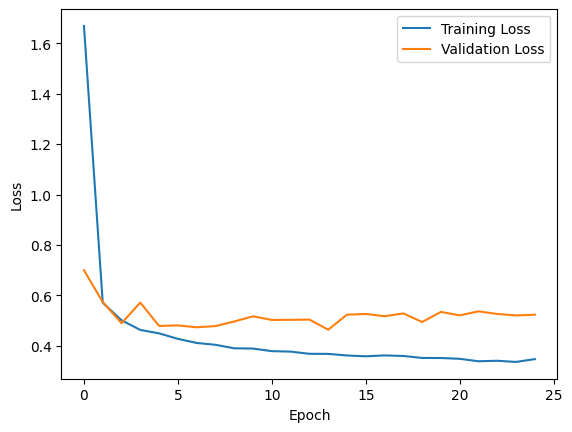

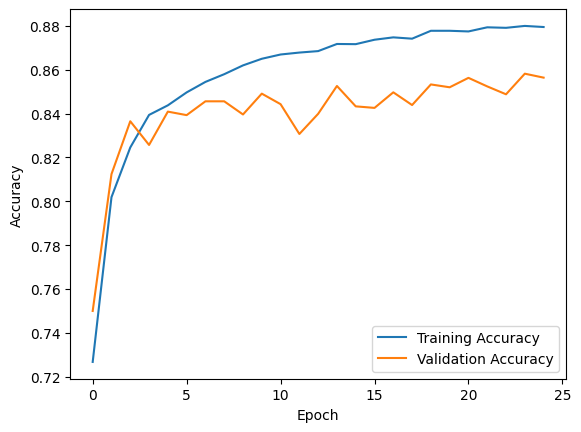

In [13]:
import matplotlib.pyplot as plt

plt.plot(updated_history.history["loss"], label="Training Loss")
plt.plot(updated_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(updated_history.history["accuracy"], label="Training Accuracy")
plt.plot(updated_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


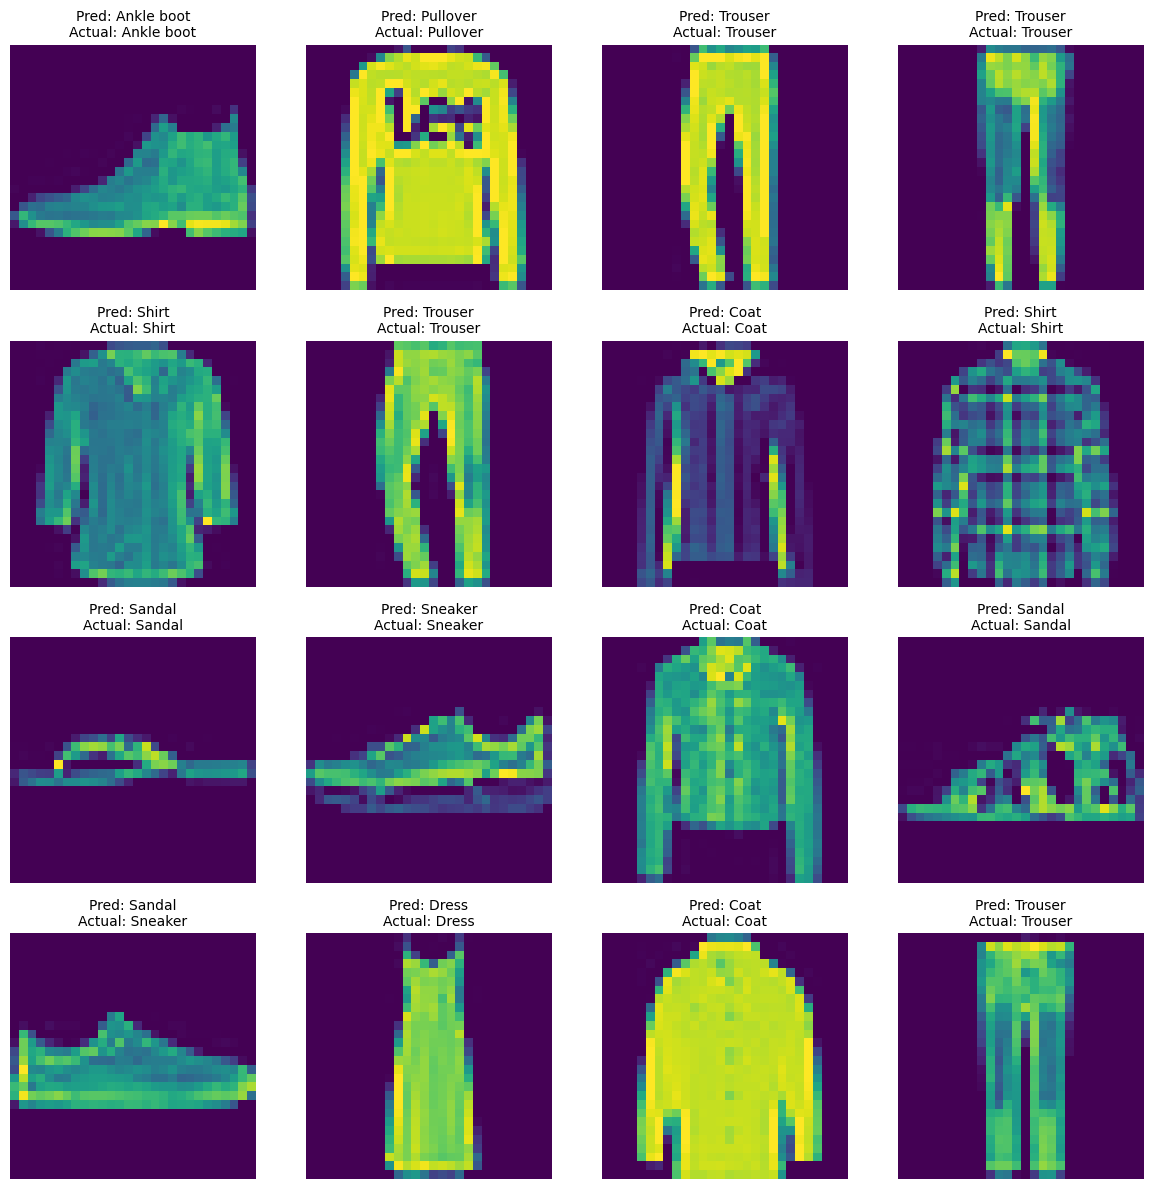

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Take exactly one batch from the evaluation dataset
for images, labels in eval_dataset.take(1):
    # Get model predictions for this batch
    batch_predictions = updated_model.predict(images)
    predicted_indices = np.argmax(batch_predictions, axis=1)

    # Number of images in this batch
    num_images = images.shape[0]

    # Configure how many images to display per row
    num_cols = 4
    num_rows = math.ceil(num_images / num_cols)

    # Create a figure with a suitable size
    plt.figure(figsize=(12, 3 * num_rows))

    for i in range(num_images):
        plt.subplot(num_rows, num_cols, i + 1)

        # Display the image
        plt.imshow(images[i].numpy())
        plt.axis('off')

        # Get predicted and actual class names
        pred_class = CLASS_NAMES[predicted_indices[i]]
        actual_class = CLASS_NAMES[labels[i].numpy()]

        # Show both predicted and actual labels as title
        plt.title(f"Pred: {pred_class}\nActual: {actual_class}", fontsize=10)

    # Adjust spacing to avoid overlapping titles, etc.
    plt.tight_layout()
    plt.show()

After adding Hidden layers 
- Loss is reduced but Accuracy not Increase
- To increase Accuracy, You have Tune Hyperparameter like BATCH_SIZE, Learning_Rate,Image Size

## Hyperparameter Tuning 

In [ ]:
# !pip install wandb weave

  Using cached protobuf-5.29.6-cp310-abi3-win_amd64.whl.metadata (592 bytes)
Using cached protobuf-5.29.6-cp310-abi3-win_amd64.whl (435 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.36.0
    Uninstalling protobuf-7.36.0:
      Successfully uninstalled protobuf-7.36.0


  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.6 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.19.5, but you have protobuf 5.29.6 which is incompatible.
langchain-google-genai 1.0.10 requires langchain-core<0.3,>=0.2.33, but you have langchain-core 0.3.74 which is incompatible.
mediapipe 0.10.14 requires protobuf<5,>=4.25.3, but you have protobuf 5.29.6 which is incompatible.
streamlit 1.36.0 requires cachetools<6,>=4.0, but you have cachetools 7.1.7 which is incompatible.
tensorflow-intel 2.17.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, but you have protobuf 5.29.6 which is incompatible.
tensorflow-metadata 1.15.0 requires protobuf<5,>=4.25.2; python_version >= "3.11", but you have prot

In [20]:
from dotenv import load_dotenv
load_dotenv()

# import os
# os.environ['WANDB_API_KEY'] = 'api_key'

True

In [21]:
!wandb login

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: iamdebasishdas123 (iamdebasishdas123-iit-dhanbad) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [14]:
import wandb
from wandb.integration.keras import WandbMetricsLogger

import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras

In [15]:
sweep_config = {

    'method' : 'grid',
    'metric' : {
        'name': 'val_accuracy',
        'goal': 'maximize'
                },
    'parameters' : {
        'batch_size': {'values': [2,4,8,16,32]},
        'learning_rate': {'values': [0.001,0.0001]},
        'hidden_nodes': {'values': [128,64]},
        'img_size': {'values': [16, 20, 28]},
        'epochs': {'values': [10,15,20,25,30]}
    }
}

sweep_id = wandb.sweep(sweep_config, project="10_mnist_new")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


Create sweep with ID: 8fd069j4
Sweep URL: https://wandb.ai/iamdebasishdas123-iit-dhanbad/10_mnist_new/sweeps/8fd069j4


In [19]:
def train_eval(batch, img_size=28):
    np.random.seed(42)  # Ensures you get the same shuffle every time

    # 1. Load the full training data (60,000 images)
    (x_train_full, y_train_full), (x_test_full, y_test_full) = fashion_mnist.load_data()



    # 3. Split into 250 training and 20 testing images
    X_train_small = x_train_full
    y_train_small = y_train_full
    
    # Resize images to match configured img_size
    X_train_full_resized = tf.image.resize(x_train_full[..., tf.newaxis], (img_size, img_size)).numpy().squeeze() 
    X_test_full_resized = tf.image.resize(x_test_full[..., tf.newaxis], (img_size, img_size)).numpy().squeeze() 
    
    
   # 3. Create full training dataset with shuffle enabled for proper training
    train_dataset = ( 
        tf.data.Dataset.from_tensor_slices((X_train_full_resized, y_train_full)) 
        .shuffle(buffer_size=60000) # Shuffles the entire training set
        .batch(batch_size=batch) 
        .prefetch(tf.data.AUTOTUNE) 
    ) 
    
    # 4. Create full evaluation dataset
    eval_dataset = ( 
        tf.data.Dataset.from_tensor_slices((X_test_full_resized, y_test_full)) 
        .batch(batch_size=batch) 
        .prefetch(tf.data.AUTOTUNE) 
    ) 
    return train_dataset,eval_dataset

In [20]:
def train():
    with wandb.init() as run:
        config=wandb.config
        IMG_HEIGHT=config.img_size
        IMG_WIDTH=config.img_size
        IMG_CHANNELS=1
        EPOCHS = config.epochs
        BATCH = config.batch_size
        CLASS_NAMES = ["T-Shirt", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
        
        train, eval = train_eval(BATCH, img_size=config.img_size)
        
        #architecture
        model = keras.Sequential([
            keras.layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
            keras.layers.Dense(config.hidden_nodes, activation="relu"),
            keras.layers.Dense(len(CLASS_NAMES), activation="softmax")
        ])

        model.compile(
            optimizer="adam",
            loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
            metrics=["accuracy"]
        )

        model.fit(
            train,
            validation_data=eval,
            epochs=EPOCHS,
            callbacks=[WandbMetricsLogger(log_freq=5)]
        )

In [33]:
# wandb.agent(sweep_id, function=train) run it for Hyperpameter tuning

## Preventing Overfiting

Finding Of Hyperparameter Tuning

batch_size:
4

epochs:
15

hidden_nodes:
128

img_size:
28

learning_rate:
0.0001



In [21]:
hp_batch_size=16
hp_epochs=30
hp_hidden=128
hp_img_size=28
hp_learning_rate=0.0001

In [22]:
train , eval = train_eval(batch=hp_batch_size,img_size=hp_img_size)

In [23]:
regularization = tf.keras.regularizers.l2(0.1)

model_hp=keras.Sequential([
            keras.layers.Flatten(input_shape=(hp_img_size, hp_img_size, IMG_CHANNELS)),
            
            keras.layers.Dense(hp_hidden,kernel_regularizer=regularization),
            keras.layers.BatchNormalization(),
            keras.layers.Activation("relu"),
            keras.layers.Dropout(0.5),
            
            keras.layers.Dense(len(CLASS_NAMES),kernel_regularizer=regularization),
            keras.layers.BatchNormalization(),
            keras.layers.Activation("softmax"),
            # keras.layers.Dropout(0.5)
        ]
    )

In [24]:
model_hp.compile(
optimizer="adam",
loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
metrics=["accuracy"],

)

history_hp=model_hp.fit(
train,
validation_data=eval,
epochs=hp_epochs,
# callbacks=[
#     tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=4,restore_best_weights=True)
# ]
)

Epoch 1/30


3750/3750 ━━━━━━━━━━━━━━━━━━━━ 26s 6ms/step - accuracy: 0.6390 - loss: 2.8240 - val_accuracy: 0.6554 - val_loss: 1.3769
Epoch 2/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - accuracy: 0.6585 - loss: 1.3858 - val_accuracy: 0.6261 - val_loss: 1.4875
Epoch 3/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.6569 - loss: 1.3971 - val_accuracy: 0.7104 - val_loss: 1.2724
Epoch 4/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.6578 - loss: 1.3986 - val_accuracy: 0.6374 - val_loss: 1.3908
Epoch 5/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.6516 - loss: 1.4052 - val_accuracy: 0.7241 - val_loss: 1.2080
Epoch 6/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.6519 - loss: 1.4134 - val_accuracy: 0.6914 - val_loss: 1.2942
Epoch 7/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.6574 - loss: 1.4147 - val_accuracy: 0.7310 - val_loss: 1.1646
Epoch 8/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.6571 - loss: 1.4086 - val

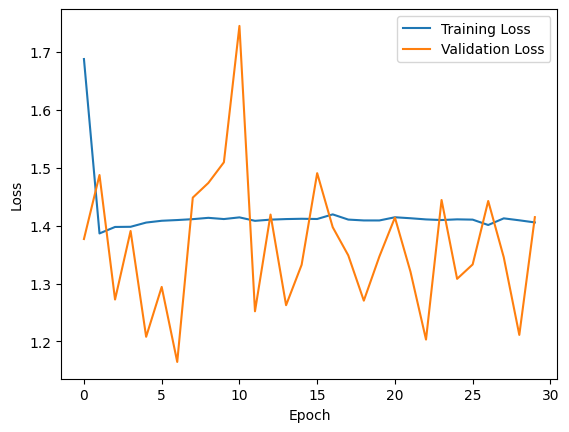

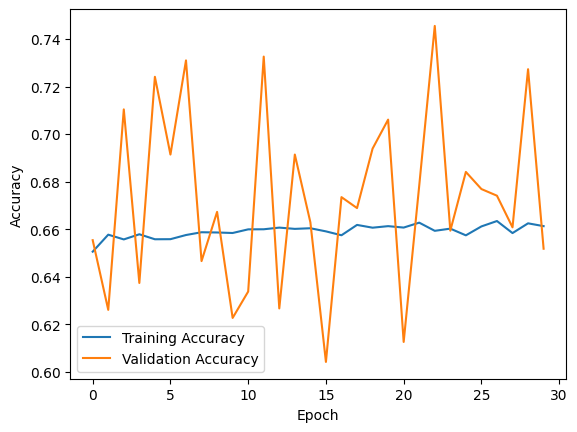

In [25]:
import matplotlib.pyplot as plt

plt.plot(history_hp.history["loss"], label="Training Loss")
plt.plot(history_hp.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(history_hp.history["accuracy"], label="Training Accuracy")
plt.plot(history_hp.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Transfer Leaning without Finetuning

- I am using Mobile net V2 Model 
It requires at least 32 X 32 image and RGB image ( 3 Channels)
but we have gray scale image  with 28 X 28 images

In [31]:

# 1. Hyperparameters
hp_img_size = 32  
num_classes = 10
batch_size = 32

# 2. Load Fashion-MNIST dataset
(x_train_full, y_train_full), (x_test_full, y_test_full) = tf.keras.datasets.fashion_mnist.load_data()

# 3. Slice exactly 1000 training samples and 100 validation samples
x_train_subset = x_train_full
y_train_subset = y_train_full

x_val_subset = x_test_full # Take a slice for validation
y_val_subset = y_test_full

# 4. Preprocessing function (Resize to 32x32, Convert to RGB, Normalize)
def preprocess_data(images, labels):
    images = tf.expand_dims(images, axis=-1)  # (28, 28) -> (28, 28, 1)
    images = tf.image.resize(images, [hp_img_size, hp_img_size])
    images = tf.image.grayscale_to_rgb(images)
    images = tf.keras.applications.mobilenet_v2.preprocess_input(images) # Scale to [-1, 1]
    return images, labels

# 5. Build efficient tf.data pipelines
train_dataset = (
    tf.data.Dataset.from_tensor_slices((x_train_subset, y_train_subset))
    .shuffle(buffer_size=1000)
    .map(preprocess_data, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(batch_size)
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)

val_dataset = (
    tf.data.Dataset.from_tensor_slices((x_val_subset, y_val_subset))
    .map(preprocess_data, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(batch_size)
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)



In [32]:
# 6. Initialize MobileNetV2 Base Model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(hp_img_size, hp_img_size, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # Freeze ImageNet weights



C:\Users\Debasish Das\AppData\Local\Temp\ipykernel_3356\4261881997.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


In [34]:
from tensorflow.keras import layers, models
# 7. Build Model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(), # Increased dropout to prevent overfitting on small data
    layers.Dense(num_classes, activation='softmax')
])

# 8. Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 9. Train the model
history = model.fit(
    train_dataset, 
    epochs=5, 
    validation_data=val_dataset
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 117s 55ms/step - accuracy: 0.3888 - loss: 1.6755 - val_accuracy: 0.4249 - val_loss: 1.4959
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 129s 69ms/step - accuracy: 0.4408 - loss: 1.4984 - val_accuracy: 0.4318 - val_loss: 1.4793
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 115s 61ms/step - accuracy: 0.4503 - loss: 1.4707 - val_accuracy: 0.4528 - val_loss: 1.4672
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 105s 56ms/step - accuracy: 0.4576 - loss: 1.4484 - val_accuracy: 0.4529 - val_loss: 1.4702
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 102s 54ms/step - accuracy: 0.4633 - loss: 1.4370 - val_accuracy: 0.4501 - val_loss: 1.4768


## Transfer learning with finetuneing

In [29]:
# 6. Initialize MobileNetV2 Base Model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(hp_img_size, hp_img_size, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = True  # Freeze ImageNet weights

C:\Users\Debasish Das\AppData\Local\Temp\ipykernel_3356\1140192497.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


In [30]:
from tensorflow.keras import layers, models
# 7. Build Model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    
    layers.Dense(num_classes, activation='softmax')
])

# 8. Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 9. Train the model
history = model.fit(
    train_dataset, 
    epochs=10, 
    validation_data=val_dataset
)

Epoch 1/10


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 582s 277ms/step - accuracy: 0.7248 - loss: 0.8278 - val_accuracy: 0.8011 - val_loss: 0.6143
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 463s 247ms/step - accuracy: 0.8709 - loss: 0.3795 - val_accuracy: 0.8677 - val_loss: 0.4065
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 472s 252ms/step - accuracy: 0.8875 - loss: 0.3389 - val_accuracy: 0.8604 - val_loss: 0.5218
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 410s 219ms/step - accuracy: 0.8968 - loss: 0.3063 - val_accuracy: 0.8086 - val_loss: 0.5534
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 373s 199ms/step - accuracy: 0.9038 - loss: 0.2792 - val_accuracy: 0.8881 - val_loss: 0.4234
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 387s 206ms/step - accuracy: 0.9110 - loss: 0.2635 - val_accuracy: 0.8981 - val_loss: 0.3473
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 352s 188ms/step - accuracy: 0.9172 - loss: 0.2424 - val_accuracy: 0.8900 - val_loss: 0.4274
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 499s 266ms/step - accuracy: 0.9